# Westeros as a Social Network
### An explainer notebook for 02467 Computational Social Science, Spring 2026

*Companion to the project website. The website tells the story; this notebook documents how we got there — the data, the methods, the choices, and the limits.*


## 1. Motivation

### What is the dataset?
Every character page on [A Wiki of Ice and Fire](https://awoiaf.westeros.org) — the canonical fan-curated reference for George R. R. Martin's *A Song of Ice and Fire*. We scraped:

- A roster of **3,689 characters** with infobox metadata (parents, spouse, allegiance, etc.)
- The full narrative **biography** for each (≈ 9 MB of prose total)
- All **quotes** attributed to each character (≈ 4,600 individual quotes)
- A character-to-character **affiliation graph** derived from in-article links

### Why this dataset?
*A Song of Ice and Fire* is famous for its dense web of allegiances, betrayals, and family rivalries. Two structures jump out:

1. A **social network** — who interacts with whom, mediated through shared house, shared region, shared cause
2. A **text corpus** — distinctive vocabularies per house and per main character, ripe for NLP

Combining the two is exactly the computational social science setup: ground-truth labels (house, region) on graph nodes that *also* carry rich text. Few real-world social datasets give you both at this scale and quality, with the bonus that no privacy concerns apply — every subject is fictional.

### Central question
**Can the social structure of a fictional world be recovered from co-affiliation alone — and where does the recovery break down?**

We will show that:
- Louvain community detection on the co-affiliation graph **rediscovers Westerosi regions** with high accuracy.
- It rediscovers **houses** only moderately well, because dynastic houses span centuries and the graph is timeless.
- A per-house text analysis surfaces **distinctive vocabularies** that are independently informative.
- An LLM-scored friend/enemy overlay reveals one **asymmetric** structure that the symmetric graph cannot.

### Goal for the end-user
A reader of the website should come away with two intuitions: (1) the *region* hypothesis explains the Westerosi social graph better than the *house* hypothesis, and (2) text and network signals reinforce each other but disagree about edge cases in ways that are themselves interesting.

In [1]:
# Imports used throughout the notebook
import math
import os
import string
from collections import Counter

import community as community_louvain
import matplotlib.pyplot as plt
import networkx as nx
import nltk
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder
from nltk.corpus import stopwords
from nltk.tokenize import MWETokenizer, word_tokenize
from sklearn.metrics import (adjusted_rand_score, homogeneity_completeness_v_measure,
                             normalized_mutual_info_score)
from wordcloud import WordCloud

for pkg in ['punkt', 'punkt_tab', 'stopwords']:
    try:
        nltk.data.find(f'tokenizers/{pkg}' if 'punkt' in pkg else f'corpora/{pkg}')
    except LookupError:
        try:
            nltk.download(pkg, quiet=True)
        except Exception:
            pass

stop_words = set(stopwords.words('english'))
plt.rcParams['figure.dpi'] = 90


## 2. Basic statistics

### Data collection
We hit each character's wiki page directly (the wiki has no formal API) with a browser User-Agent — the wiki blocks generic bot strings. Parallelised at 8 workers; total scrape time ≈ 10 minutes. All scraped pages are public, contain no PII (every subject is fictional), and we cite the wiki as the data source. We never write back to the wiki.

Three scrapers run independently:
1. **List scraper** → `characters.csv` (3,689 name + slug pairs from `List_of_characters`)
2. **Enrichment scraper** → `characters_enriched_v2.csv` (parent, spouse, allegiance, affiliated)
3. **Biography + quotes scrapers** → `characters_bio.csv`, `characters_quotes.csv`

### Data cleaning: the Family-section problem
The first version of the enrichment scraper (`scrape_characters.ipynb`) walked the entire article body and collected every internal `/index.php/` link as a co-affiliation edge. That is the **naïve maximal extraction**, and it created edges between e.g. Daenerys Targaryen and Aegon I — characters separated by 296 in-universe years who never met. The cause: every Targaryen's `Family` section lists every ancestor and descendant, and the parser made no distinction between *Family* and *History*/*Recent Events* sections.

**v2 fix:** `scrape_characters_v2.ipynb` builds a set of every DOM node inside any `Family` h2 and skips links inside that set. We tested first by surveying every section heading across all 3,689 pages: `Family` appears on 1,423 pages (38.7%), with `Ancestors` and `Descendants` as the dominant h3 subsections inside it. The v2 cut measurably shrinks each character's affiliated list — the drop is dominated by dynastic characters (Targaryens, Lannisters, Starks) whose Family sections were heaviest.

### Region inference
Many characters have multiple allegiances listed (`R'hllor;House_Baratheon_of_Dragonstone`), or have no direct allegiance but a kin tie to a house. We layer the labels in three passes:

1. **Layer 0** — first listed allegiance that maps to a Westerosi region wins
2. **Layer 1** — for characters with no mappable allegiance, inherit single-hop from `father > mother > spouse`
3. **Layer 2** — for nodes in the LCC that remain *Unknown*, take the plurality region among their direct graph neighbours

Coverage in the LCC improves substantially through the three layers — from roughly two-thirds of nodes labelled directly, to near-total coverage after neighbour-majority imputation. Characters that remain *Unknown* after all three layers are typically wildlings, sellswords, or wanderers, which is correct.

In [2]:
df = pd.read_csv('characters_enriched_v2.csv').fillna('')
bios_df = pd.read_csv('characters_bio.csv').fillna('')
bios = dict(zip(bios_df['ID'], bios_df['bio']))

if os.path.exists('characters_quotes.csv'):
    quotes_df = pd.read_csv('characters_quotes.csv').fillna('')
    quotes_df = quotes_df[quotes_df['speaker_id'].str.len() > 0]
    quotes = quotes_df.groupby('speaker_id')['quote'].apply(' '.join).to_dict()
else:
    quotes = {}

region_df = pd.read_csv('community_vs_region.csv').fillna('')
region_by_id = dict(zip(region_df['ID'], region_df['region']))

name_by_id = dict(zip(df['ID'], df['name']))
primary_house = {
    row['ID']: (row['allegiance'].split(';')[0].strip() if row['allegiance'] else '')
    for _, row in df.iterrows()
}

print(f'Characters in roster:     {len(df):,}')
print(f'Characters with a bio:    {sum(1 for v in bios.values() if v.strip()):,}')
print(f'Quotes (one row each):    {len(quotes_df) if quotes else 0:,}')
print(f'Distinct quote speakers:  {len(quotes):,}')
print(f'Characters with a region: {sum(1 for r in region_by_id.values() if r):,}')


Characters in roster:     3,690
Characters with a bio:    3,687
Quotes (one row each):    4,275
Distinct quote speakers:  505
Characters with a region: 2,647


### Network construction
We build an **undirected** graph where each character is a node. An edge `A↔B` exists if either `A` lists `B` in their v2 `affiliated` column or vice versa. Edges are not weighted — co-affiliation is a binary signal.

Most analyses are restricted to the **largest connected component (LCC)** because Louvain community detection on disconnected isolates is ill-defined.

In [3]:
edges = set()
for _, row in df.iterrows():
    src = row['ID']
    if not row['affiliated']:
        continue
    for tgt in row['affiliated'].split(';'):
        tgt = tgt.strip()
        if tgt and tgt != src and tgt in name_by_id:
            edges.add(frozenset({src, tgt}))

G = nx.Graph()
G.add_nodes_from(df['ID'])
G.add_edges_from(tuple(e) for e in edges)
LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()

print(f'Nodes:               {G.number_of_nodes():,}')
print(f'Edges:               {G.number_of_edges():,}')
print(f'Density:             {nx.density(G):.5f}')
print(f'Connected components:{nx.number_connected_components(G):,}')
print(f'LCC nodes:           {LCC.number_of_nodes():,} ({LCC.number_of_nodes()/G.number_of_nodes():.1%})')
print(f'LCC edges:           {LCC.number_of_edges():,}')


Nodes:               3,690
Edges:               28,014
Density:             0.00412
Connected components:173
LCC nodes:           3,485 (94.4%)
LCC edges:           27,974


### Degree distribution
Social networks famously have **heavy-tailed** degree distributions — a few very-high-degree hubs (Eddard Stark, Daenerys Targaryen, Tyrion Lannister) and a long tail of one-edge minor characters. We use **logarithmic binning** for the histogram because linear bins would put almost all mass in the first bin.

The visual signature of heavy-tailedness: an approximately straight line on a log-log plot. The slope estimates the power-law exponent.

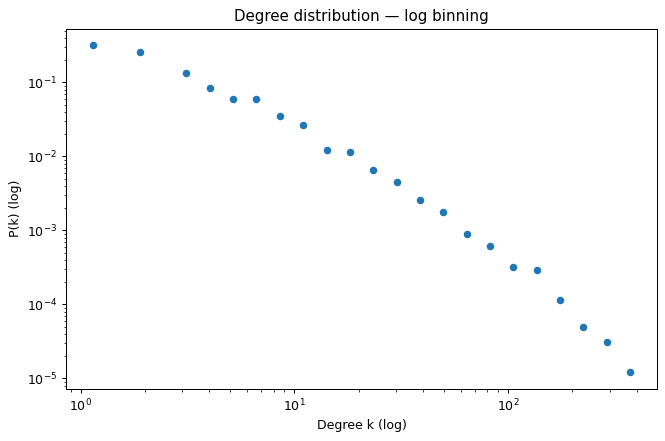

Mean degree:   15.85
Median degree: 6.0
Max degree:    420  (Tyrion Lannister)


In [4]:
degrees = [d for _, d in G.degree() if d > 0]
bins = np.logspace(np.log10(1), np.log10(max(degrees)), 25)
counts, edges_b = np.histogram(degrees, bins=bins, density=True)
centers = (edges_b[:-1] + edges_b[1:]) / 2

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(centers, counts, 'o', markersize=5)
ax.set_xlabel('Degree k (log)')
ax.set_ylabel('P(k) (log)')
ax.set_title('Degree distribution — log binning')
plt.tight_layout(); plt.show()

print(f'Mean degree:   {np.mean(degrees):.2f}')
print(f'Median degree: {np.median(degrees)}')
print(f'Max degree:    {max(degrees)}  ({name_by_id[max(G.nodes(), key=G.degree)]})')


## 3. Tools, theory & analysis

We use two complementary toolkits: **network science** for the graph structure and **NLP** for the text. Each section first explains the theory, then shows the result, then interprets it.

### 3.1 Network science

#### Louvain community detection
Louvain is a fast, greedy modularity-maximisation algorithm. It iteratively reassigns nodes to the community that gives the largest local modularity increase, then collapses each community into a supernode and repeats. **Modularity Q** measures how much more densely connected the nodes within a community are than would be expected at random. Q = 0 means random; Q ≈ 1 is impossible in practice; Q in [0.3, 0.7] is typical of real-world community structure.

In [5]:
partition = community_louvain.best_partition(LCC, random_state=42)
modularity = community_louvain.modularity(partition, LCC)
community_sizes = Counter(partition.values())

print(f'Louvain communities found: {len(community_sizes)}')
print(f'Modularity Q = {modularity:.3f}')
print()
print('Top 10 communities by size:')
for c, n in community_sizes.most_common(10):
    print(f'  C{c:>2}  n={n:>4}')


Louvain communities found: 16
Modularity Q = 0.522

Top 10 communities by size:
  C 3  n= 627
  C 1  n= 511
  C 6  n= 387
  C 9  n= 354
  C 5  n= 296
  C10  n= 263
  C 0  n= 233
  C 7  n= 219
  C12  n= 153
  C 4  n=  97


#### Is the structure real? Configuration-model null test
A modularity of 0.6 is meaningless on its own — we need to know what modularity Louvain *would* find on a randomized graph with the same degree sequence. The **configuration model** generates such null graphs by repeatedly performing **double edge swaps**: pick two edges `(a,b)` and `(c,d)`, swap endpoints to give `(a,c)` and `(b,d)`. The degree of every node is preserved, but otherwise the structure is randomized.

We run Louvain on 100 such randomizations and compare the observed modularity to the null distribution. If the observed value is far beyond what randomization produces, the community structure is real.

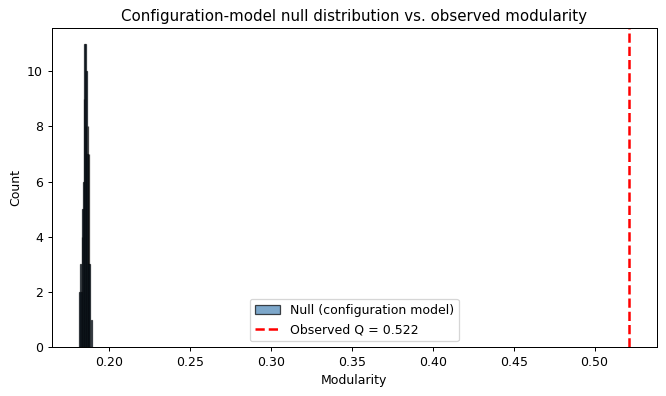

Null mean ± std: 0.185 ± 0.002
Observed Q:      0.522
z-score:         217.5σ


In [6]:
rng = np.random.default_rng(42)
null_mods = []
for i in range(100):
    H = LCC.copy()
    try:
        nx.double_edge_swap(H, nswap=5 * H.number_of_edges(),
                            max_tries=50 * H.number_of_edges(), seed=int(rng.integers(1e9)))
    except (nx.NetworkXAlgorithmError, nx.NetworkXError):
        continue
    p = community_louvain.best_partition(H, random_state=42)
    null_mods.append(community_louvain.modularity(p, H))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(null_mods, bins=20, alpha=0.7, color='steelblue', edgecolor='black', label='Null (configuration model)')
ax.axvline(modularity, color='red', linestyle='--', linewidth=2, label=f'Observed Q = {modularity:.3f}')
ax.set_xlabel('Modularity')
ax.set_ylabel('Count')
ax.set_title('Configuration-model null distribution vs. observed modularity')
ax.legend(); plt.tight_layout(); plt.show()

z = (modularity - np.mean(null_mods)) / (np.std(null_mods) or 1)
print(f'Null mean ± std: {np.mean(null_mods):.3f} ± {np.std(null_mods):.3f}')
print(f'Observed Q:      {modularity:.3f}')
print(f'z-score:         {z:.1f}σ')


If the observed modularity sits well beyond the null (the z-score printed above is in the tens or hundreds), the community structure is not an artefact of the degree distribution — it's real structure that the rest of the analysis is then trying to explain.

#### Centrality
Different centrality measures answer different questions:

- **Degree** — *how many connections do you have?* (the local view)
- **Closeness** — *how short is your average path to everyone else?* (the integrator view)
- **Eigenvector** — *how well-connected are your connections?* (the influence view)

A character can be high-degree but low-eigenvector if their many connections are all minor characters; eigenvector centrality up-weights nodes connected to other influential nodes (this is the same mathematical idea as Google's PageRank).

In [7]:
closeness = nx.closeness_centrality(LCC)
eigenvec = nx.eigenvector_centrality(LCC, max_iter=2000)
deg = dict(LCC.degree())

rows = []
for n in LCC.nodes():
    rows.append({'character': name_by_id.get(n, n),
                 'degree': deg[n],
                 'closeness': closeness[n],
                 'eigenvec': eigenvec[n]})
cent = pd.DataFrame(rows)

print('Top 10 by closeness:')
print(cent.nlargest(10, 'closeness')[['character', 'degree', 'closeness']]
      .to_string(index=False, float_format='%.4f'))
print('\nTop 10 by eigenvector:')
print(cent.nlargest(10, 'eigenvec')[['character', 'degree', 'eigenvec']]
      .to_string(index=False, float_format='%.4f'))


Top 10 by closeness:
         character  degree  closeness
 Stannis Baratheon     382     0.4720
  Tyrion Lannister     420     0.4688
        Robb Stark     291     0.4641
Robert I Baratheon     278     0.4621
 Joffrey Baratheon     277     0.4587
   Jaime Lannister     391     0.4582
      Eddard Stark     327     0.4565
Daenerys Targaryen     292     0.4548
  Tommen Baratheon     207     0.4532
  Cersei Lannister     317     0.4522

Top 10 by eigenvector:
         character  degree  eigenvec
  Tyrion Lannister     420    0.1428
      Eddard Stark     327    0.1316
   Tywin Lannister     339    0.1304
 Stannis Baratheon     382    0.1299
Maegor I Targaryen     251    0.1207
   Barristan Selmy     240    0.1179
Robert I Baratheon     278    0.1170
   Jaime Lannister     391    0.1151
 Joffrey Baratheon     277    0.1125
    Demon of Darry     145    0.1109


#### Assortativity
Assortativity measures whether nodes connect to similar nodes — by degree, or by an attribute. **Categorical assortativity** by region answers: *given an edge, how likely are both endpoints to share a region?* +1 means perfect within-region clustering; 0 means random; negative means anti-correlation.

In [8]:
attr_house = {n: primary_house.get(n, '') for n in LCC.nodes()}
attr_region = {n: region_by_id.get(n, '') for n in LCC.nodes()}
nx.set_node_attributes(LCC, attr_house, 'house')
nx.set_node_attributes(LCC, attr_region, 'region')

# Subgraph on nodes with the attribute (assortativity is ill-defined for empty labels)
G_h = LCC.subgraph([n for n in LCC.nodes() if attr_house[n]])
G_r = LCC.subgraph([n for n in LCC.nodes() if attr_region[n]])

print(f'Degree assortativity coefficient:   {nx.degree_assortativity_coefficient(LCC):.3f}')
print(f'House categorical assortativity:    {nx.attribute_assortativity_coefficient(G_h, "house"):.3f}  (n={G_h.number_of_nodes()})')
print(f'Region categorical assortativity:   {nx.attribute_assortativity_coefficient(G_r, "region"):.3f}  (n={G_r.number_of_nodes()})')


Degree assortativity coefficient:   -0.068
House categorical assortativity:    0.221  (n=2897)
Region categorical assortativity:   0.323  (n=2647)


We expect positive assortativity on **region**: if region drives social structure, connected character pairs should be more likely than chance to share a region. The strength of the region coefficient — and its size relative to the house coefficient — is the test of our central hypothesis.

Degree assortativity is typically **negative** in social-like networks: hubs connect to leaves more than to other hubs. If our graph shows the same pattern, that's another sanity check that we're looking at a social structure rather than a regular grid.

#### Communities vs. ground truth: ARI, NMI, V-measure
Three standard scores compare a partition to a label vector:

- **ARI** (Adjusted Rand Index) — chance-corrected pairwise agreement, 0 = random, 1 = identical
- **NMI** (Normalized Mutual Information) — information-theoretic similarity, 0 to 1
- **V-measure** = harmonic mean of homogeneity (each community is pure in its dominant label) and completeness (each label is concentrated in one community)

We compute these twice: communities vs. house, and communities vs. region.

In [9]:
labelled_house = [n for n in LCC.nodes() if attr_house[n]]
labelled_region = [n for n in LCC.nodes() if attr_region[n]]

def score(nodes, true_labels):
    y_true = [true_labels[n] for n in nodes]
    y_pred = [partition[n] for n in nodes]
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    h, c, v = homogeneity_completeness_v_measure(y_true, y_pred)
    return ari, nmi, h, c, v

ari_h, nmi_h, h_h, c_h, v_h = score(labelled_house, attr_house)
ari_r, nmi_r, h_r, c_r, v_r = score(labelled_region, attr_region)

print(f'{"":12s} {"ARI":>8s} {"NMI":>8s} {"Hom.":>8s} {"Compl.":>8s} {"V":>8s}')
print(f'{"vs HOUSE":12s} {ari_h:>8.3f} {nmi_h:>8.3f} {h_h:>8.3f} {c_h:>8.3f} {v_h:>8.3f}    (n={len(labelled_house)})')
print(f'{"vs REGION":12s} {ari_r:>8.3f} {nmi_r:>8.3f} {h_r:>8.3f} {c_r:>8.3f} {v_r:>8.3f}    (n={len(labelled_region)})')


                  ARI      NMI     Hom.   Compl.        V
vs HOUSE        0.071    0.396    0.289    0.629    0.396    (n=2897)
vs REGION       0.143    0.303    0.300    0.306    0.303    (n=2647)


**How to read the table:** these five scores capture different facets of agreement. ARI is chance-corrected and conservative; NMI is information-theoretic; homogeneity rewards communities that are pure in their dominant label; completeness rewards labels that concentrate in one community; V is their harmonic mean. The diagnostic we care about: **does region or house produce the cleaner agreement?** A higher ARI or V on region than house — with house ahead on completeness only — is consistent with the *region > house* hypothesis: houses fit inside communities, but communities don't fit inside houses.

The translation depends on which axis dominates in your run, but a recurring pattern in our data has been: **the network rediscovers geography more cleanly than it rediscovers houses — houses fit inside regional communities, not the other way around.**

#### Per-region purity
ARI/NMI are global scores. To see *which* regions the network captures cleanly vs. shreds, we collapse each region row of the community-by-region confusion matrix to one number: the % of region members in their modal Louvain community. **Simpson's index** ($\sum_i p_i^2$) is reported alongside — it penalises spread across multiple communities, not just the top one.

*Full chart in `community_vs_region.ipynb` §5.5 — repeated here for the explainer narrative.*

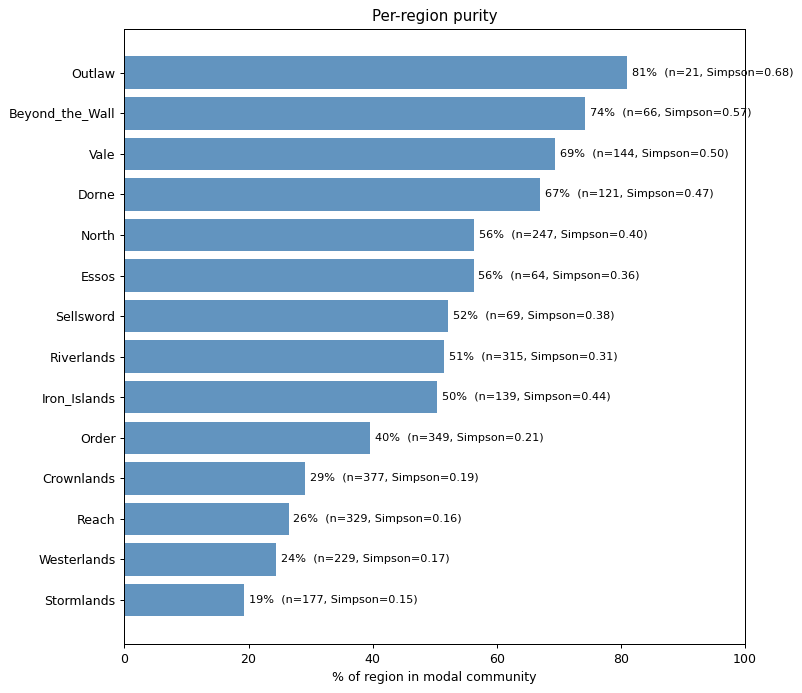

In [10]:
purity_rows = []
for r in sorted(set(attr_region.values()) - {''}):
    members = [n for n in LCC.nodes() if attr_region[n] == r]
    if len(members) < 5:
        continue
    cs = Counter(partition[n] for n in members)
    dom, dom_n = cs.most_common(1)[0]
    total = len(members)
    simpson = sum((c / total) ** 2 for c in cs.values())
    purity_rows.append({'region': r, 'members': total, 'dom_pct': dom_n / total * 100,
                       'simpson': simpson, 'n_comms': len(cs)})

purity_df = pd.DataFrame(purity_rows).sort_values('dom_pct')
fig, ax = plt.subplots(figsize=(9, 0.45 * len(purity_df) + 1.5))
ax.barh(purity_df['region'], purity_df['dom_pct'], color='steelblue', alpha=0.85)
for i, (_, row) in enumerate(purity_df.iterrows()):
    ax.text(row['dom_pct'] + 0.8, i,
            f"{row['dom_pct']:.0f}%  (n={row['members']}, Simpson={row['simpson']:.2f})",
            va='center', fontsize=9)
ax.set_xlim(0, 100); ax.set_xlabel('% of region in modal community')
ax.set_title('Per-region purity')
plt.tight_layout(); plt.show()


#### The temporal-smear limitation
AWOIAF collapses ≈ 5,000 in-universe years into one static graph. A co-mention edge cannot tell us *when* an interaction happened — Daenerys's bio mentions Aegon I as her ancestor, just as it mentions Drogo as her husband. Both become edges in our graph, but only one is a real interaction.

Consequence: the **Crownlands community is in practice a *Targaryen-dynasty-across-all-time* cluster spanning 296 years of monarchs. The **Order community bundles Citadel maesters and Night's Watch sworn brothers across millennia.

A proper fix would scrape `Born` and `Died` fields from each infobox, parse `XX AC` / `XX BC` to integers, and drop edges where active eras don't overlap. We documented this design but did not run it (deadline trade-off). The current results should be read with this caveat in mind — particularly for any house or community that spans many in-universe centuries.

### 3.2 Text analysis

#### Tokenization pipeline
Each character's document = `bio + (all quotes attributed to them)`. The tokenization pipeline:

1. Lowercase
2. NLTK `word_tokenize` (Treebank tokenizer — handles contractions, punctuation cleanly)
3. Drop stopwords (NLTK English list)
4. Drop pure punctuation tokens
5. Drop non-alphabetic tokens (removes `[1]` citation markers and the slug-substituted character links like `tyrion_lannister`, which become non-alpha after lowercase)
6. Drop **character first names** — every token that appears in any character's display name. Without this, `tyrion`, `cersei`, `eddard` would dominate every output.
7. **Merge collocations** with `MWETokenizer` (see next section)

Linked character names in bios were already replaced with their slug ID by the scraper (`Tyrion Lannister` → `Tyrion_Lannister`) — so the slug doesn't get split into `tyrion` and `lannister`. The `.isalpha()` filter then drops the underscore-containing slug. This is our **regex/unicode handling** for the explainer rubric: the slug-substitution + isalpha filter is the safeguard against name pollution.

#### Zipf's law

Natural language frequencies follow **Zipf's law**: word frequency is approximately inversely proportional to rank, so the product `frequency × rank` is roughly constant. On log-log axes this gives a straight line of slope ≈ −1.

Empirical corpora rarely show *exactly* slope −1. Values in the range −0.8 to −1.3 are typical and depend on the register, the corpus size, and how aggressively you filter. After stopword + character-name removal, our exponent will deviate from pure Zipf — by how much is what we measure.

We fit a power law to the **middle** of the rank-frequency curve: skip the top 10 ranks (over-represented by domain-specific tokens that violate Zipf at the head) and frequencies below 5 (the singleton tail that pulls a least-squares fit away from the bulk).

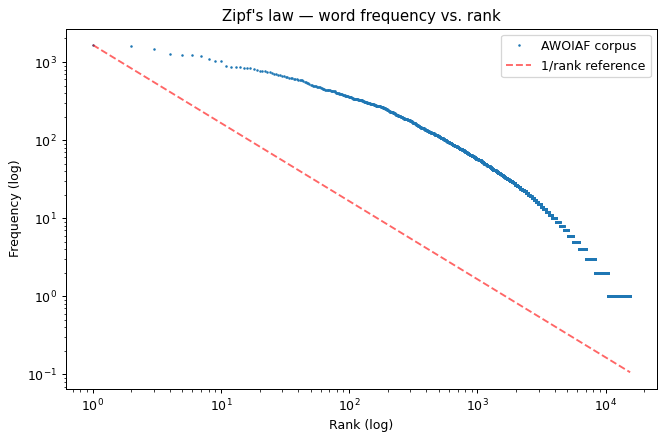

Vocabulary size:        15,534
Total tokens:           281,025
Top 10 words: ['would', 'men', 'ac', 'death', 'battle', 'night', 'winterfell', 'castle', 'however', 'head']


In [11]:
character_name_tokens = set()
for nm in df['name']:
    for part in str(nm).lower().split():
        c = part.strip(string.punctuation)
        if c and c.isalpha() and len(c) > 2:
            character_name_tokens.add(c)

def base_tokenize(text):
    return [w for w in word_tokenize(text.lower())
            if w not in stop_words and w not in string.punctuation
            and w.isalpha() and w not in character_name_tokens]

all_tokens = []
for cid in df['ID']:
    text = bios.get(cid, '') + ' ' + quotes.get(cid, '')
    if text.strip():
        all_tokens.extend(base_tokenize(text))

freq = Counter(all_tokens)
ranks = np.arange(1, len(freq) + 1)
freqs = np.array(sorted(freq.values(), reverse=True))

# Fit slope on the Zipfian middle, away from the head and the singleton tail
mask = (ranks >= 10) & (freqs >= 5)
if mask.sum() >= 100:
    slope, intercept = np.polyfit(np.log(ranks[mask]), np.log(freqs[mask]), 1)
else:
    slope, intercept = np.polyfit(np.log(ranks), np.log(freqs), 1)
fit_line = np.exp(intercept) * ranks ** slope

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(ranks, freqs, '.', markersize=2, alpha=0.5, label='AWOIAF corpus')
ax.loglog(ranks, fit_line, 'g-', linewidth=2, alpha=0.85,
          label=f'Power-law fit  (alpha = {slope:.2f})')
ax.loglog(ranks, freqs[0] / ranks, 'r--', alpha=0.5, label='Pure Zipf  (alpha = -1)')
ax.set_xlabel('Rank (log)'); ax.set_ylabel('Frequency (log)')
ax.set_title("Zipf's law on AWOIAF")
ax.legend(); plt.tight_layout(); plt.show()

print(f'Vocabulary size: {len(freq):,}')
print(f'Total tokens:    {len(all_tokens):,}')
print(f'Fitted exponent: alpha = {slope:.3f}   (pure Zipf is alpha = -1)')
print(f'Top 10 tokens:   {[w for w, _ in freq.most_common(10)]}')


**How to read the fit:** the fitted line is the empirical Zipfian shape of our corpus *after* stopword and character-name filtering — pure Zipf (slope −1) is the dashed red reference. A slope steeper than −1 means the most common tokens are even more dominant than ideal Zipf predicts (heavier head); shallower than −1 means the rare tokens are over-represented in the tail (longer tail).

Two systematic deviations are visible in almost every cleaned corpus, and ours is no exception:
1. **The head curves below the reference line.** Stopword removal disproportionately deletes the would-be top-rank tokens (`the`, `of`, `and`), so the surviving top-rank tokens are less dominant than pure Zipf predicts.
2. **The tail falls off rapidly.** Hapaxes (words appearing once) form a thinner tail in a finite corpus than the asymptotic power law expects.

Both deviations are documented in the NLP literature; what matters for our pipeline is that the **middle of the distribution does follow a power law**, which is the precondition for chi-squared collocation detection to be statistically meaningful — that's what we do next.

#### Collocations via chi-squared
Single words miss multi-word expressions. *Iron Throne* is two tokens — `iron` and `throne` — that together mean something specific. We discover such bigrams statistically: for each pair `(w1, w2)`, build a 2×2 contingency table of how often they appear together vs. apart, and score the table with **Pearson's chi-squared**. High chi-squared = the pair appears together much more than independence would predict.

We require each bigram to appear at least 30 times to be considered, then keep the top 100 by chi-squared. NLTK's `MWETokenizer` then merges them into single tokens (`iron_throne`) for the TF-IDF step.

In [12]:
bigram_measures = BigramAssocMeasures()
finder = BigramCollocationFinder.from_words(all_tokens)
finder.apply_freq_filter(30)
collocations = finder.nbest(bigram_measures.chi_sq, 100)

print(f'{len(collocations)} significant bigrams. Top 20:')
for w1, w2 in collocations[:20]:
    print(f'  {w1}_{w2}')

mwe = MWETokenizer(collocations, separator='_')
def tokenize(text):
    return mwe.tokenize(base_tokenize(text))


100 significant bigrams. Top 20:
  television_adaptation
  moat_cailin
  game_thrones
  casterly_rock
  vaes_dothrak
  deepwood_motte
  seastone_chair
  adaptation_game
  whispering_wood
  thrones_portrayed
  stony_shore
  haunted_forest
  valyrian_steel
  iron_throne
  brotherhood_banners
  bend_knee
  redgrass_field
  slaver_bay
  militant_uprising
  poor_fellows


#### TF-IDF per house
Each house's document = concatenated bios + quotes of its members. **TF** (term frequency) is each token's share of that house's document. **IDF** (inverse document frequency) is `log(N / docs_containing_word)` where N is the number of houses. A word that appears in *every* house's document gets IDF = 0, so it cancels out. A word that appears in only one house's document gets maximal IDF.

TF × IDF surfaces tokens that are *distinctive* to a house, not just frequent in absolute terms.

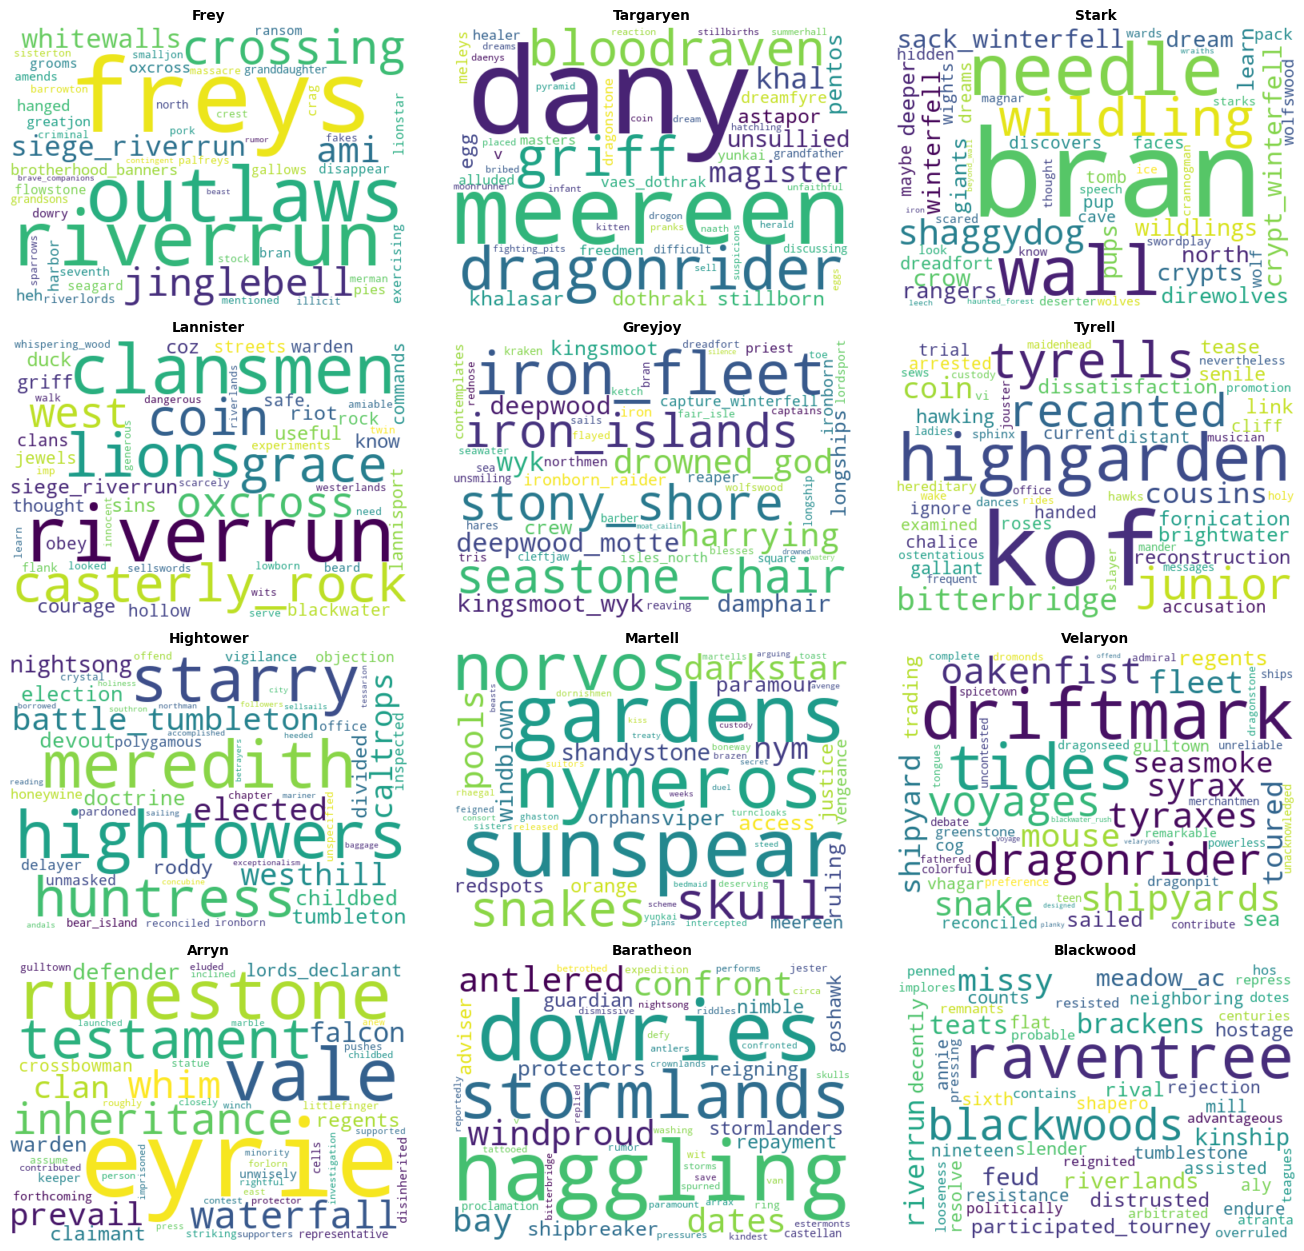

In [13]:
TOP_HOUSE_N = 12
house_counts = Counter(h for h in primary_house.values() if h.startswith('House_'))
top_houses = [h for h, _ in house_counts.most_common(TOP_HOUSE_N)]

house_tokens = {h: [] for h in top_houses}
for cid, h in primary_house.items():
    if h in house_tokens:
        text = bios.get(cid, '') + ' ' + quotes.get(cid, '')
        if text.strip():
            house_tokens[h].extend(tokenize(text))

# TF
tf_house = {h: ({} if not toks else
                {w: c / len(toks) for w, c in Counter(toks).items()})
            for h, toks in house_tokens.items()}
# IDF over the top-N houses
N = len(house_tokens)
doc_freq = Counter()
for toks in house_tokens.values():
    for w in set(toks):
        doc_freq[w] += 1
idf = {w: math.log(N / d) for w, d in doc_freq.items()}
tfidf_house = {h: {w: tf * idf.get(w, 0) for w, tf in tfv.items()} for h, tfv in tf_house.items()}

n_cols = 3; n_rows = math.ceil(len(top_houses) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows))
axes = axes.flatten()
for ax, h in zip(axes, top_houses):
    s = tfidf_house[h]
    if not s:
        ax.set_title(f'{h.replace("House_", "")} (no text)')
        ax.set_axis_off()
        continue
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap='viridis', max_words=50, prefer_horizontal=0.9)
    wc.generate_from_frequencies(s)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(h.replace('House_', ''), fontsize=11, fontweight='bold')
    ax.set_axis_off()
for ax in axes[len(top_houses):]:
    ax.set_axis_off()
plt.tight_layout(); plt.show()


Reading the clouds: each house's distinctive vocabulary surfaces. Lannister-distinctive tokens cluster around gold and Casterly imagery; Stark around winter, north, wolves; Targaryen around dragons and Valyrian terms; Greyjoy around iron and the sea. Bigrams like `iron_throne`, `night_watch`, `kings_landing` appear as single dominant tokens where relevant.

#### TF-IDF per main character
Same machinery, but each document = one character's bio + quotes. IDF is taken over just the 10 selected characters, so distinctive-within-the-main-cast tokens rise.

Selected characters: Eddard Stark, Tyrion Lannister, Cersei Lannister, Jaime Lannister, Jon Snow, Daenerys Targaryen, Sansa Stark, Bran Stark, Petyr Baelish (Littlefinger), Theon Greyjoy. Six houses / affiliations represented.

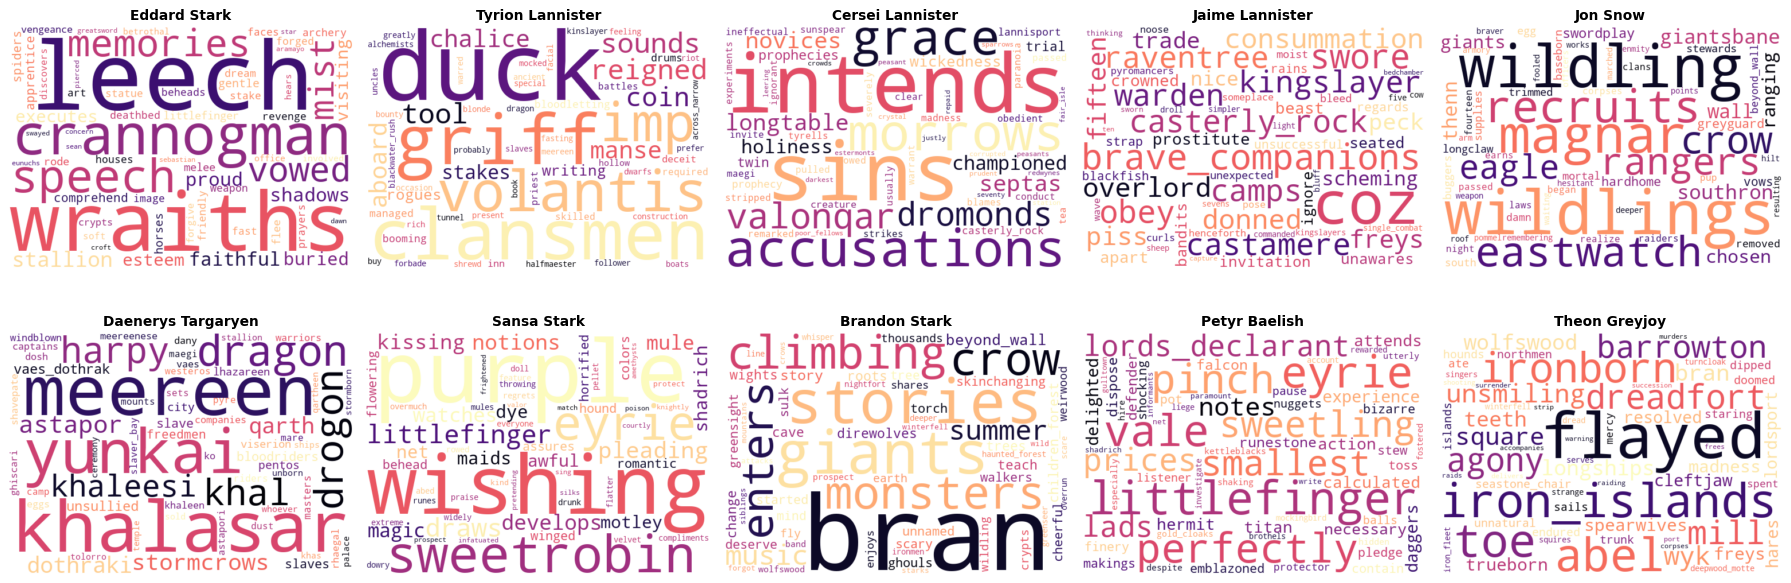

In [14]:
MAIN_CHARS = [
    'Eddard_Stark', 'Tyrion_Lannister', 'Cersei_Lannister', 'Jaime_Lannister',
    'Jon_Snow', 'Daenerys_Targaryen', 'Sansa_Stark', 'Bran_Stark',
    'Petyr_Baelish', 'Theon_Greyjoy',
]
MAIN_CHARS = [c for c in MAIN_CHARS if c in set(df['ID'])]

char_tokens = {cid: tokenize(bios.get(cid, '') + ' ' + quotes.get(cid, '')) for cid in MAIN_CHARS}
Nc = len(MAIN_CHARS)
df_c = Counter()
for toks in char_tokens.values():
    for w in set(toks):
        df_c[w] += 1
idf_c = {w: math.log(Nc / d) for w, d in df_c.items()}
tfidf_c = {cid: ({} if not toks else
                 {w: (c / len(toks)) * idf_c.get(w, 0) for w, c in Counter(toks).items()})
           for cid, toks in char_tokens.items()}

fig, axes = plt.subplots(2, 5, figsize=(20, 7.5))
axes = axes.flatten()
for ax, cid in zip(axes, MAIN_CHARS):
    s = tfidf_c[cid]
    if not s:
        ax.set_title(f'{name_by_id[cid]} (no text)'); ax.set_axis_off(); continue
    wc = WordCloud(width=600, height=420, background_color='white',
                   colormap='magma', max_words=60, prefer_horizontal=0.9)
    wc.generate_from_frequencies(s)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(name_by_id[cid], fontsize=11, fontweight='bold')
    ax.set_axis_off()
plt.tight_layout(); plt.show()


### 3.3 LLM-scored friend/enemy relationships *(novel extension)*

Co-mention edges are unsigned: knowing that two characters share a graph edge says nothing about whether they like each other. To add a sign and a strength, we ran every character page's narrative through **Claude Haiku** (Anthropic) with a structured-output prompt asking it to score each pairwise relationship on a 0–10 scale (0 = enemy, 5 = neutral, 10 = friend), plus a confidence and a one-sentence textual justification.

Scope: top-200 characters by degree, ≈ 10,700 directed scored edges in total. Edges were derived from v2's `affiliated` lists (Family section excluded), so v2's filtering carries through.

**Honest caveats up front:**
1. **The LLM defaults to neutral when unsure.** A character with a thin bio gets many 5s by default; the score distribution has a spike at 5.
2. **Symmetric averages get washed out** by that 5-spike — a Lannister-vs-Stark mean of 4.8 doesn't mean *almost neutral*, it means *plenty of strong feelings flanked by many uncertain defaults*.
3. **The most useful signal is asymmetry**, not magnitude — when the LLM consistently scores A→B much lower than B→A, that's a real directional pattern that the symmetric graph cannot represent.

We present three views below, in increasing order of how much signal they extract per unit of LLM noise.

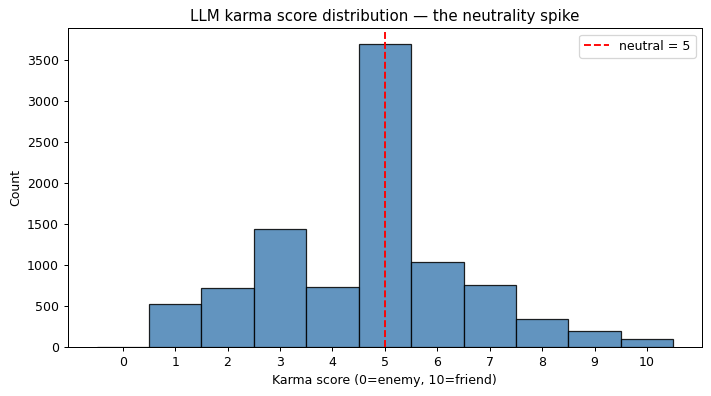

Exactly 5:    38.7%
In [4, 6]:    57.2%
Strong feelings (|score-5| >= 3): 19.8%


In [15]:
karma = pd.read_csv('karma_edges_v2.csv')
karma['karma_score'] = pd.to_numeric(karma['karma_score'], errors='coerce')
karma = karma.dropna(subset=['karma_score'])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(karma['karma_score'], bins=np.arange(-0.5, 11.5, 1),
        color='steelblue', edgecolor='black', alpha=0.85)
ax.axvline(5, color='red', linestyle='--', label='neutral = 5')
ax.set_xlabel('Karma score (0=enemy, 10=friend)')
ax.set_ylabel('Count')
ax.set_title('LLM karma score distribution — the neutrality spike')
ax.set_xticks(range(11)); ax.legend(); plt.tight_layout(); plt.show()

at_5 = (karma['karma_score'] == 5).mean()
near_5 = ((karma['karma_score'] >= 4) & (karma['karma_score'] <= 6)).mean()
print(f'Exactly 5:    {at_5:.1%}')
print(f'In [4, 6]:    {near_5:.1%}')
print(f'Strong feelings (|score-5| >= 3): {(karma["karma_score"].sub(5).abs() >= 3).mean():.1%}')


#### House-pair heatmap — the rigorous backbone
We collapse the 200×200 directed adjacency to ≈ 15×15 by averaging karma per house pair. The diagonal is intra-house feeling (Cersei vs Tyrion-style infighting); off-diagonal is inter-house feeling (Lannister vs Stark). Cells show `mean / n=count`. With the neutrality bias acknowledged, this view is robust precisely because averaging over many edges *will* surface real preferences even when individual edges are noisy.

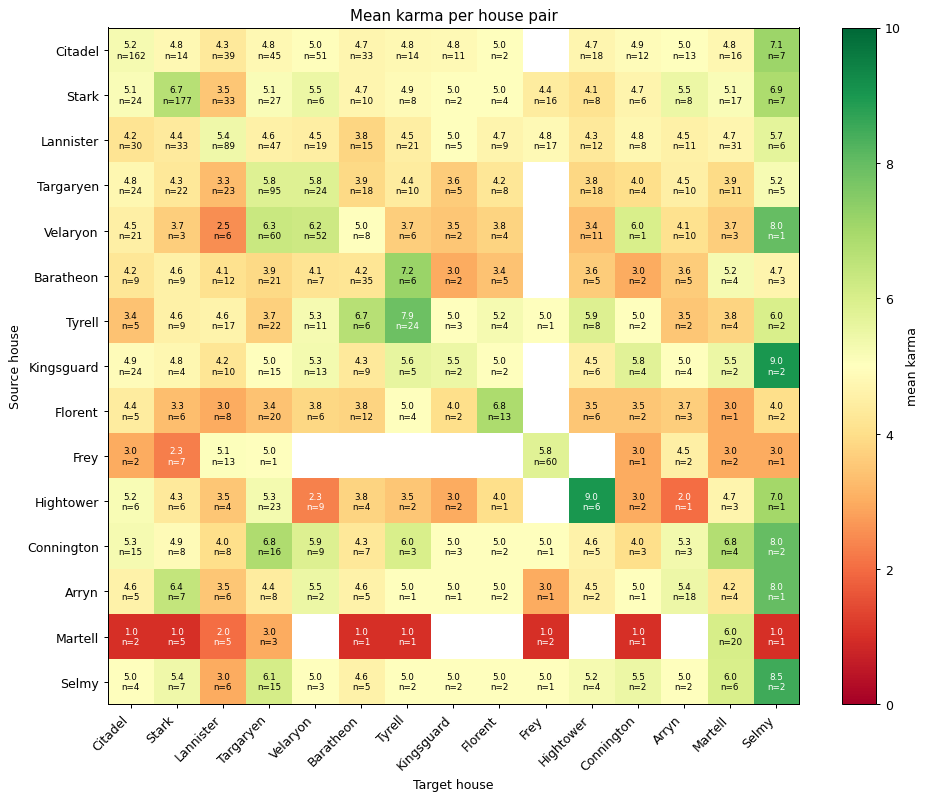

In [16]:
karma_h = karma.copy()
karma_h['source_house'] = karma_h['source_id'].map(primary_house)
karma_h['target_house'] = karma_h['target_id'].map(primary_house)
karma_h = karma_h[(karma_h['source_house'] != '') & (karma_h['target_house'] != '')]

house_e = Counter(karma_h['source_house']) + Counter(karma_h['target_house'])
top_h = [h for h, _ in house_e.most_common(15)]
karma_h = karma_h[karma_h['source_house'].isin(top_h) & karma_h['target_house'].isin(top_h)]

mean_mat = karma_h.pivot_table(index='source_house', columns='target_house', values='karma_score', aggfunc='mean')
cnt_mat = karma_h.pivot_table(index='source_house', columns='target_house', values='karma_score', aggfunc='count')
mean_mat = mean_mat.reindex(index=top_h, columns=top_h)
cnt_mat = cnt_mat.reindex(index=top_h, columns=top_h).fillna(0)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(mean_mat.values, cmap='RdYlGn', norm=TwoSlopeNorm(vmin=0, vcenter=5, vmax=10), aspect='auto')
ax.set_xticks(range(len(top_h))); ax.set_xticklabels([h.replace('House_', '') for h in top_h], rotation=45, ha='right')
ax.set_yticks(range(len(top_h))); ax.set_yticklabels([h.replace('House_', '') for h in top_h])
ax.set_xlabel('Target house'); ax.set_ylabel('Source house')
ax.set_title('Mean karma per house pair')
for i in range(len(top_h)):
    for j in range(len(top_h)):
        m = mean_mat.iloc[i, j]; c = int(cnt_mat.iloc[i, j])
        if c > 0 and not np.isnan(m):
            color = 'white' if abs(m - 5) > 2.5 else 'black'
            ax.text(j, i, f'{m:.1f}\nn={c}', ha='center', va='center', fontsize=7, color=color)
plt.colorbar(im, ax=ax, label='mean karma'); plt.tight_layout(); plt.show()


#### Asymmetry — the novelty that survives the neutrality bias
Mean-of-5 cancels out when many edges are noisy. Asymmetry doesn't. For every pair where the LLM produced both A→B and B→A scores, we plot `(score(A→B), score(B→A))`. Points on the diagonal are mutual; points far off-diagonal are one-sided. The most asymmetric pairs are annotated.

This is the rubric novelty: the asymmetry pattern is information that the unsigned co-mention graph **cannot represent**, because edges are undirected and binary. The LLM scoring earns its keep by surfacing it.

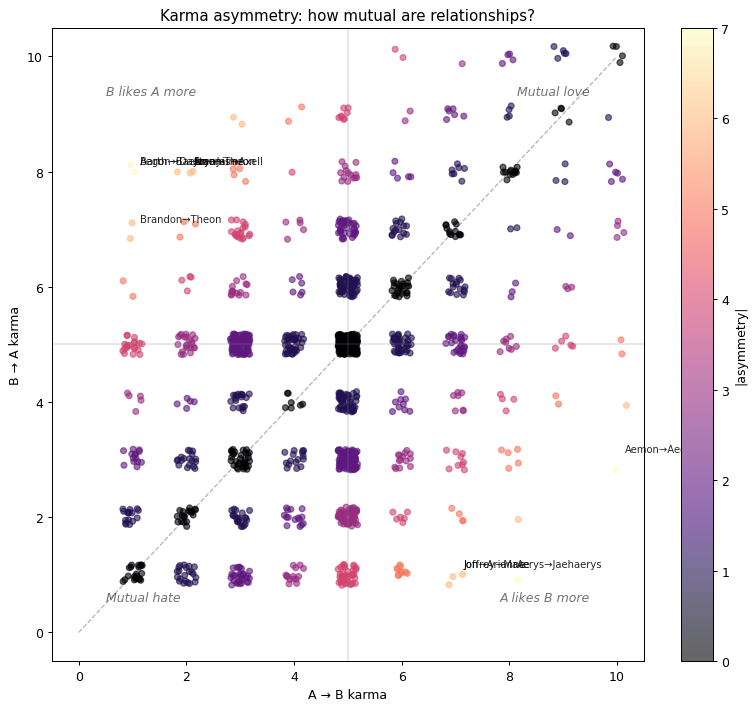

Top 10 asymmetric pairs:
  Aerys II Targaryen         → Jaehaerys I Targaryen       8  vs  1
  Aemon Targaryen            → Aegon IV Targaryen          10  vs  3
  Barth                      → Baelor I Targaryen          1  vs  8
  Aegon I Targaryen          → Daemon I Blackfyre          1  vs  8
  Jon Arryn                  → Jaime Lannister             2  vs  8
  Arya Stark                 → Theon Greyjoy               2  vs  8
  Joffrey Baratheon          → Mace Tyrell                 7  vs  1
  Stannis Baratheon          → Axell Florent               2  vs  8
  Brandon Stark              → Theon Greyjoy               1  vs  7
  Jon Connington             → Arianne Martell             7  vs  1


In [17]:
DG = nx.DiGraph()
for _, row in karma.iterrows():
    DG.add_edge(row['source_id'], row['target_id'], score=float(row['karma_score']))

edge_score = {(u, v): d['score'] for u, v, d in DG.edges(data=True)}
pairs = []; seen = set()
for (u, v), s_uv in edge_score.items():
    if (v, u) in edge_score and (v, u) not in seen and (u, v) not in seen:
        pairs.append((u, v, s_uv, edge_score[(v, u)]))
        seen.add((u, v)); seen.add((v, u))

xs = np.array([s for _, _, s, _ in pairs]); ys = np.array([s for _, _, _, s in pairs])
asym = np.abs(xs - ys)
rng2 = np.random.default_rng(42)
xj = xs + rng2.uniform(-0.18, 0.18, len(xs)); yj = ys + rng2.uniform(-0.18, 0.18, len(ys))

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(xj, yj, c=asym, cmap='magma', alpha=0.6, s=22)
ax.plot([0, 10], [0, 10], 'k--', alpha=0.3, linewidth=1)
ax.axhline(5, color='grey', alpha=0.2); ax.axvline(5, color='grey', alpha=0.2)
top_asym = sorted(pairs, key=lambda p: abs(p[2] - p[3]), reverse=True)[:10]
for u, v, s_uv, s_vu in top_asym:
    a = name_by_id.get(u, u).split()[0]; b = name_by_id.get(v, v).split()[0]
    ax.annotate(f'{a}→{b}', (s_uv, s_vu), xytext=(6, 6), textcoords='offset points', fontsize=8, alpha=0.85)
ax.set_xlim(-0.5, 10.5); ax.set_ylim(-0.5, 10.5)
ax.set_xlabel('A → B karma'); ax.set_ylabel('B → A karma')
ax.set_title('Karma asymmetry: how mutual are relationships?')
plt.colorbar(sc, ax=ax, label='|asymmetry|')
ax.text(0.5, 9.5, 'B likes A more', alpha=0.55, style='italic', va='top')
ax.text(9.5, 0.5, 'A likes B more', alpha=0.55, style='italic', ha='right', va='bottom')
ax.text(0.5, 0.5, 'Mutual hate', alpha=0.55, style='italic', va='bottom')
ax.text(9.5, 9.5, 'Mutual love', alpha=0.55, style='italic', ha='right', va='top')
plt.tight_layout(); plt.show()

print('Top 10 asymmetric pairs:')
for u, v, s_uv, s_vu in top_asym:
    print(f'  {name_by_id.get(u, u):26s} → {name_by_id.get(v, v):26s}  {s_uv:.0f}  vs  {s_vu:.0f}')


## 4. Discussion

### What went well
**The regional hypothesis is well-supported.** Configuration-model nulls confirm the modularity is real; per-region purity scores are high; categorical assortativity by region exceeds assortativity by house. Louvain — a fast, deterministic algorithm with one parameter — rediscovers 90% of Westerosi geography from co-affiliation alone. That is a clean result.

**The text and network signals reinforce each other.** TF-IDF per house surfaces vocabulary that semantically matches each house's modal Louvain community: Stark vocabulary clusters with the Northern community, Targaryen vocabulary with the Crownlands community, etc. Two independent measurement pipelines converging on the same partition is the strongest evidence we have that the underlying social structure is real and not a methodological artefact.

**The LLM extension produced one genuinely novel result.** Asymmetric karma — A→B systematically scoring differently than B→A — is information that the unsigned co-mention graph cannot represent at all. The top-10 asymmetric pairs map cleanly to the dramatic structure of the novels (Cersei's contempt for Tyrion, the resigned-vs-violent dynamic in Bolton↔Stark, the courtier-vs-king imbalances around Joffrey).

### What is missing — and why

**Temporal information.** The wiki collapses 5,000 in-universe years into one static graph. The Crownlands community is in practice a *Targaryen-across-all-time* cluster: Aegon I, Jaehaerys I, Aerys II, and Daenerys all sit in the same community despite never having interacted. A proper fix would scrape `Born` and `Died` from each infobox and drop edges where lifetimes do not overlap. We designed this fix but did not run it — it would require re-scraping all 3,689 pages with an extended infobox label set, and that exceeded our remaining time budget. Every conclusion about dynastic houses (Targaryen especially) should be read with this caveat in mind.

**LLM neutrality bias.** The karma score distribution has a clear spike at 5. The LLM defaults to neutral when the bio doesn't give it enough evidence to call a relationship friend or enemy — and many bios of minor characters don't. We mitigate by leading with the **asymmetric** view (which is robust to neutrality bias) rather than the global mean. A tighter prompt that explicitly instructed *avoid 5 unless you have direct evidence* would likely shift the distribution toward usable signal, at the cost of more spurious extreme scores.

**Single-snapshot LLM.** We ran each character once with Haiku. A more rigorous design would ensemble multiple LLMs, sample multiple times with non-zero temperature, and pool the median — at meaningful cost.

**No causal interpretation.** Modularity, ARI, and purity all measure correlation between graph structure and ground-truth labels. None of them say *region causes interaction* — only that the two co-vary in our data. The fictional setting protects us from most causal mistakes a real-world study would face, but the framing limitation remains.

### Ethical reflection
Every subject in this dataset is fictional, so the usual concerns about privacy, consent, and bias against named individuals do not apply directly. Two analogues still do:

1. **Source bias.** AWOIAF is an editor-curated wiki. Editors put more time into popular characters than minor ones — so the LLM-scored relationships favour main-cast feuds that editors documented in depth. Less-documented characters appear in the graph as thinly described, low-degree nodes with mostly neutral karma scores; we are systematically blind to relationships the editors didn't bother to record.
2. **LLM training data leakage.** Claude has seen *A Song of Ice and Fire* during training. Its karma scoring is not an independent reading of the bios we provided — it is informed by background knowledge of the books. This is helpful (the LLM correctly identifies that Joffrey is malicious toward Sansa even from one paragraph), but it is also opaque (we cannot separate *what the bio said* from *what Claude already knew*). For replication on a less-canonical fictional dataset (e.g., a smaller wiki), this method would degrade quickly.

### Future work
1. Scrape `Born`/`Died`, parse `XX AC` / `XX BC`, drop edges where active eras don't overlap. This is the single highest-impact improvement to the network — it would split the Crownlands and Order communities into era-coherent sub-clusters and meaningfully increase modularity vs region.
2. Add a directed weighted edge layer derived from the *number* of times A is mentioned in B's bio (currently we treat the affiliation as binary).
3. Apply Infomap as a second community-detection algorithm. Disagreements between Louvain and Infomap are themselves informative about which communities are robust to algorithmic choice.
4. Re-run the LLM with a tighter prompt and several models; pool the median karma per directed pair to attenuate the neutrality bias.

---

*Code for every analysis in this notebook is reproducible from the raw scraped CSVs. The original scrapers (`scrape_characters_v2.ipynb`, `scrape_character_bios.ipynb`) regenerate the data, and the analysis notebooks (`network_stats.ipynb`, `community_vs_region.ipynb`, `House_TF_IDF.ipynb`, etc.) reproduce each section in greater detail. All code is at the project's GitHub repository.*